In [19]:
from typing import Tuple, Dict, Any, cast
import numpy as np
import neurokit2 as nk
from scipy.signal import welch
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# https://chatgpt.com/c/69dfa307-fc9c-8384-b590-0d0a869feb48


parallel_path = Path.home() / "DI/2025_ZIVEO/PROJECT_TRAIN_UNET/SUPL_FUNCTIONS"
sys.path.append(str(parallel_path))

try:
    from zive_data_read_utils import read_json_file, load_ecg_npy, get_rpeaks, find_matching_ecg_file, lowcut_filter
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        f"Could not import zive_data_read_utils from: {parallel_path}"
    ) from e
    
def build_qrs_mask(
    n: int,
    rpeaks: np.ndarray,
    fs: int = 200,
    qrs_left_ms: int = 80,
    qrs_right_ms: int = 120
) -> np.ndarray:
    """
    Build boolean mask:
      True  = keep sample
      False = mask out QRS neighborhood
    """
    keep = np.ones(n, dtype=bool)

    left = int(round(qrs_left_ms * fs / 1000.0))
    right = int(round(qrs_right_ms * fs / 1000.0))

    for rp in np.asarray(rpeaks, dtype=int):
        a = max(0, rp - left)
        b = min(n, rp + right + 1)
        keep[a:b] = False

    return keep


def extract_unmasked_runs(
    x: np.ndarray,
    keep_mask: np.ndarray,
    min_run_len: int = 32
) -> Tuple[np.ndarray, list[tuple[int, int]]]:
    """
    Extract contiguous kept runs and concatenate them into one residual vector.
    """
    x = np.asarray(x, dtype=float).ravel()
    keep_mask = np.asarray(keep_mask, dtype=bool)

    runs: list[tuple[int, int]] = []
    start = None

    for i, k in enumerate(keep_mask):
        if k and start is None:
            start = i
        elif (not k) and (start is not None):
            if i - start >= min_run_len:
                runs.append((start, i))
            start = None

    if start is not None and len(x) - start >= min_run_len:
        runs.append((start, len(x)))

    if not runs:
        return np.array([], dtype=float), runs

    residual = np.concatenate([x[a:b] for a, b in runs])
    return residual, runs


def _band_power(f: np.ndarray, pxx: np.ndarray, band: tuple[float, float]) -> float:
    lo, hi = band
    m = (f >= lo) & (f <= hi)
    if not np.any(m):
        return 0.0
    return float(np.trapz(pxx[m], f[m]))


def classify_noise_from_psd(
    residual: np.ndarray,
    fs: int = 200,
    band_50: tuple[float, float] = (48.0, 52.0),
    band_emg: tuple[float, float] = (20.0, 80.0),
    band_motion: tuple[float, float] = (0.1, 5.0),
    band_total: tuple[float, float] = (0.1, 90.0),
    min_peak_prominence_ratio: float = 3.0,
) -> dict:
    """
    Classify noise on QRS-masked residual using PSD.
    """
    residual = np.asarray(residual, dtype=float).ravel()

    if residual.size < max(64, fs):
        return {
            "label": "mixed_or_unclear",
            "scores": {
                "powerline_50hz": 0.0,
                "emg_broadband": 0.0,
                "motion_artifact": 0.0,
            },
            "features": {
                "reason": "Residual signal too short after QRS masking."
            },
            "freqs": None,
            "psd": None,
        }

    residual = residual - np.mean(residual)

    nperseg = min(len(residual), max(128, 2 * fs))
    if nperseg % 2 == 1:
        nperseg -= 1
    nperseg = max(64, nperseg)

    f, pxx = welch(
        residual,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend="constant",
        scaling="density",
    )

    eps = 1e-16

    total_power = _band_power(f, pxx, band_total) + eps
    power_50 = _band_power(f, pxx, band_50)
    power_emg = _band_power(f, pxx, band_emg)
    power_motion = _band_power(f, pxx, band_motion)

    m50 = (f >= band_50[0]) & (f <= band_50[1])
    if np.any(m50):
        p50_max = float(np.max(pxx[m50]))
        f50_peak = float(f[m50][np.argmax(pxx[m50])])
    else:
        p50_max = 0.0
        f50_peak = None

    memg = (f >= band_emg[0]) & (f <= band_emg[1])
    mexc50 = (f >= 47.0) & (f <= 53.0)
    memg_bg = memg & (~mexc50)

    if np.any(memg_bg):
        emg_bg_mean = float(np.mean(pxx[memg_bg])) + eps
        p_emg_bg = pxx[memg_bg] + eps
        spectral_flatness_emg = float(np.exp(np.mean(np.log(p_emg_bg))) / np.mean(p_emg_bg))
    else:
        emg_bg_mean = eps
        spectral_flatness_emg = 0.0

    peak_prominence_ratio = p50_max / emg_bg_mean

    r50 = power_50 / total_power
    remg = power_emg / total_power
    rmotion = power_motion / total_power

    score_powerline = r50 * min(peak_prominence_ratio / min_peak_prominence_ratio, 3.0)
    score_emg = remg * (0.5 + spectral_flatness_emg) / max(1.0, peak_prominence_ratio / min_peak_prominence_ratio)
    score_motion = rmotion

    scores = {
        "powerline_50hz": float(score_powerline),
        "emg_broadband": float(score_emg),
        "motion_artifact": float(score_motion),
    }

    best_name = max(scores, key=scores.get)
    sorted_scores = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
    best_score = sorted_scores[0][1]
    second_score = sorted_scores[1][1]

    is_strong_50hz = (r50 > 0.08) and (peak_prominence_ratio >= min_peak_prominence_ratio)
    is_emg_like = (remg > 0.20) and (spectral_flatness_emg > 0.2) and not is_strong_50hz
    is_motion_like = (rmotion > 0.35)

    if is_strong_50hz and best_name == "powerline_50hz":
        label = "powerline_50hz"
    elif is_motion_like and best_name == "motion_artifact":
        label = "motion_artifact"
    elif is_emg_like and best_name == "emg_broadband":
        label = "emg_broadband"
    else:
        if best_score < 0.05 or (second_score > 0 and best_score / second_score < 1.3):
            label = "mixed_or_unclear"
        else:
            label = best_name

    return {
        "label": label,
        "scores": scores,
        "features": {
            "relative_power_50hz": float(r50),
            "relative_power_emg": float(remg),
            "relative_power_motion": float(rmotion),
            "peak_50hz_frequency": f50_peak,
            "peak_50hz_prominence_ratio": float(peak_prominence_ratio),
            "spectral_flatness_emg_band": float(spectral_flatness_emg),
            "total_power_ref_band": float(total_power),
            "residual_length_samples": int(len(residual)),
        },
        "freqs": f,
        "psd": pxx,
    }


def classify_ecg_noise_segment_qrs_masked(
    x: np.ndarray,
    fs: int = 200,
    correct_artifacts: bool = False,
    qrs_left_ms: int = 80,
    qrs_right_ms: int = 120,
    min_run_len_ms: int = 120,
) -> dict:
    """
    ECG-specific classifier:
      1) detect R-peaks with get_rpeaks()
      2) mask QRS neighborhoods
      3) classify residual PSD as:
         - powerline_50hz
         - emg_broadband
         - motion_artifact
         - mixed_or_unclear
    """
    x = np.asarray(x, dtype=float).ravel()

    if x.size < max(64, fs):
        raise ValueError("Segment too short.")

    rpeaks_samples, rpeaks_seconds = get_rpeaks(
        ecg_signal=x,
        fs=fs,
        correct_artifacts=correct_artifacts
    )
    
    print(rpeaks_samples, rpeaks_seconds)

    keep_mask = build_qrs_mask(
        n=len(x),
        rpeaks=rpeaks_samples,
        fs=fs,
        qrs_left_ms=qrs_left_ms,
        qrs_right_ms=qrs_right_ms,
    )

    min_run_len = max(8, int(round(min_run_len_ms * fs / 1000.0)))
    residual, runs = extract_unmasked_runs(
        x=x,
        keep_mask=keep_mask,
        min_run_len=min_run_len
    )

    res = classify_noise_from_psd(residual=residual, fs=fs)

    if "features" not in res:
        res["features"] = {}

    res["features"].update({
        "n_samples_total": int(len(x)),
        "n_rpeaks_used": int(len(rpeaks_samples)),
        "fraction_unmasked": float(np.mean(keep_mask)),
        "qrs_left_ms": int(qrs_left_ms),
        "qrs_right_ms": int(qrs_right_ms),
        "min_run_len_ms": int(min_run_len_ms),
        "correct_artifacts": bool(correct_artifacts),
    })

    res["rpeaks_samples"] = rpeaks_samples
    res["rpeaks_seconds"] = rpeaks_seconds
    res["keep_mask"] = keep_mask
    res["runs"] = runs
    res["residual"] = residual

    return res



def plot_qrs_masked_noise_analysis(x: np.ndarray, res: dict, fs: int = 200) -> None:
    x = np.asarray(x).ravel()
    t = np.arange(len(x)) / fs
    keep = res["keep_mask"]

    plt.figure(figsize=(12, 4))
    plt.plot(t, x, linewidth=1, label="ECG")

    masked = ~keep
    in_block = False
    start = None

    for i, m in enumerate(masked):
        if m and not in_block:
            start = i
            in_block = True
        elif not m and in_block:
            plt.axvspan(start / fs, i / fs, alpha=0.2)
            in_block = False

    if in_block:
        plt.axvspan(start / fs, len(x) / fs, alpha=0.2)

    rp = np.asarray(res["rpeaks_samples"], dtype=int)
    rp = rp[(rp >= 0) & (rp < len(x))]
    plt.plot(rp / fs, x[rp], "o", markersize=4, label="R peaks")

    plt.title(f"ECG with QRS-masked zones, predicted: {res['label']}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # if res["freqs"] is not None and res["psd"] is not None:
    #     plt.figure(figsize=(10, 4))
    #     plt.semilogy(res["freqs"], res["psd"], linewidth=1)
    #     plt.axvspan(48, 52, alpha=0.2, label="50 Hz")
    #     plt.axvspan(20, 80, alpha=0.15, label="EMG")
    #     plt.axvspan(0.1, 5, alpha=0.15, label="Motion")
    #     plt.title("PSD of QRS-masked residual")
    #     plt.xlabel("Frequency (Hz)")
    #     plt.ylabel("PSD")
    #     plt.legend()
    #     plt.tight_layout()
    #     plt.show()
        
        
    if res["freqs"] is not None and res["psd"] is not None:
        plt.figure(figsize=(10, 4))
        plt.semilogy(res["freqs"], res["psd"], linewidth=1, color="black", label="PSD")

        # Highlight typical noise bands with distinct colors
        plt.axvspan(48, 52, color="red", alpha=0.25, label="50 Hz")
        plt.axvspan(20, 80, color="orange", alpha=0.18, label="EMG")
        plt.axvspan(0.1, 5, color="blue", alpha=0.18, label="Motion")

        plt.title("PSD of QRS-masked residual")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD")
        plt.legend()
        plt.tight_layout()
        plt.show()        


In [20]:

# Input
dir_path = Path("~/DI/2025_ZIVEO/DUOMENYS_ANOTUOTI/AtsisiuntimasZiveDuomenu/Atsisiusti_visi_anotuoti_duomenys_26_04_14").expanduser()

basename = "1630968.676"
# 1015_24	1630968.676	0	11110	K., eina per visą įrašą bangelės, bet sužymėjus,
# kur jos išlenda ryškiau ir sužymėjus fragmentus su mra, galima būtų priskirti net 1111, arba bent 2222     

# JSON path
json_path = dir_path / f"{basename}.json"

# Find matching ECG file (works for paired_decimal / paired_npy / auto)
ecg_path = find_matching_ecg_file(
    folder=dir_path,
    basename=basename,
    data_format="auto"
)

if ecg_path is None:
    raise FileNotFoundError(f"No matching ECG file found for basename: {basename}")

if not json_path.exists():
    raise FileNotFoundError(f"JSON metadata file not found: {json_path}")

# Read data
signal = load_ecg_npy(ecg_path)
metadata = read_json_file(json_path)


# Example output
print(f"basename   : {basename}")
print(f"ECG file   : {ecg_path}")
print(f"JSON file  : {json_path}")
print(f"signal shape: {signal.shape}")
print(f"metadata keys: {list(metadata.keys())}")


basename   : 1630968.676
ECG file   : /home/kesju/DI/2025_ZIVEO/DUOMENYS_ANOTUOTI/AtsisiuntimasZiveDuomenu/Atsisiusti_visi_anotuoti_duomenys_26_04_14/1630968.676
JSON file  : /home/kesju/DI/2025_ZIVEO/DUOMENYS_ANOTUOTI/AtsisiuntimasZiveDuomenu/Atsisiusti_visi_anotuoti_duomenys_26_04_14/1630968.676.json
signal shape: (127999,)
metadata keys: ['recordingId', 'channelCount', 'userId', 'flags', 'noises', 'noises_annotated', 'rpeakAnnotationCounts', 'rpeaks']


[  88  297  509  743  963 1196 1415 1623 1852 2075 2294 2531 2756 2981] [ 0.44   1.485  2.545  3.715  4.815  5.98   7.075  8.115  9.26  10.375
 11.47  12.655 13.78  14.905]
Predicted label: motion_artifact
Scores:
  motion_artifact   : 0.7756
  emg_broadband     : 0.0327
  powerline_50hz    : 0.0004
Features:
  relative_power_50hz: 0.001187255432692784
  relative_power_emg: 0.027136995508391378
  relative_power_motion: 0.7755577539764825
  peak_50hz_frequency: 48.0
  peak_50hz_prominence_ratio: 0.9549129082172769
  spectral_flatness_emg_band: 0.7047325673487279
  total_power_ref_band: 0.00023098171803245088
  residual_length_samples: 1220
  n_samples_total: 3000
  n_rpeaks_used: 14
  fraction_unmasked: 0.4066666666666667
  qrs_left_ms: 160
  qrs_right_ms: 500
  min_run_len_ms: 120
  correct_artifacts: False


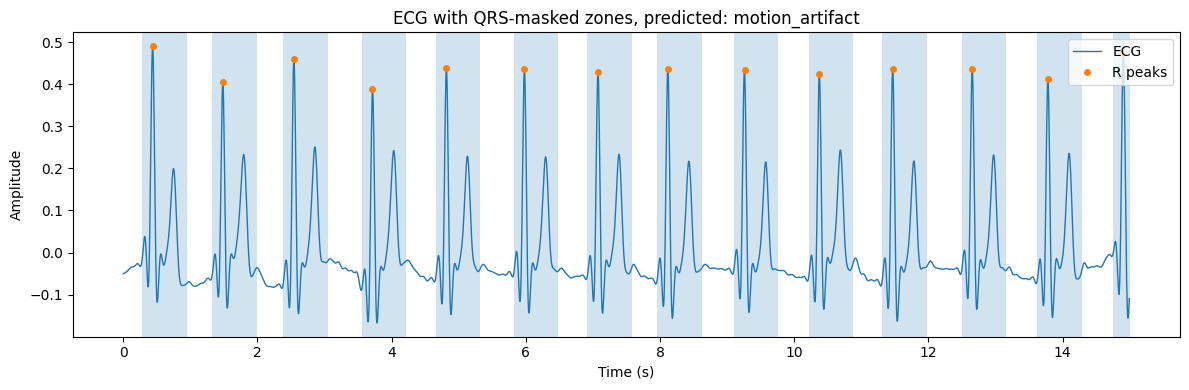

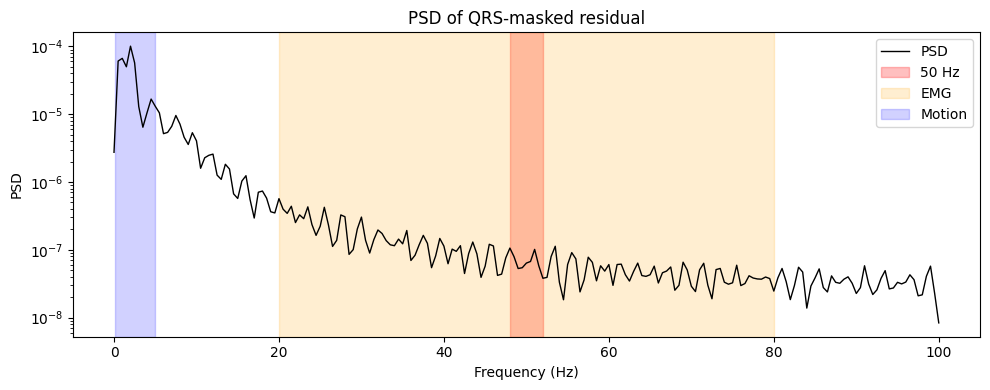

In [ ]:

# APDOROJIMAS *********************************************

# signal_flt = lowcut_filter(signal)
# signal_flt = signal
# signal_flt = nk.signal_filter(signal, sampling_rate=200, lowcut=0.5, method='butterworth', order=4)
signal_flt = nk.signal_filter(signal, sampling_rate=200, lowcut=0.5, highcut=40., method='butterworth', order=4)
# signal_flt = nk.signal_filter(signal, sampling_rate=200, lowcut=0.5, highcut=30., method='butterworth', order=4)
# signal_flt = nk.signal_filter(signal, sampling_rate=200, lowcut=0.5, highcut=20., method='butterworth', order=4)
# signal_flt = nk.signal_filter(signal, sampling_rate=200, lowcut=0.5, highcut=10., method='butterworth', order=4)


# ecg_segment = signal_flt[:200*10]  # First 10 seconds at 200 Hz
# ecg_segment = signal_flt[150:200*8]  # From 2 to 8 seconds at 200 Hz

# nuo 4500 iki 7500
ecg_segment = signal_flt[4500:7500]  # From 2 to 8 seconds at 200 Hz

res = classify_ecg_noise_segment_qrs_masked(
    x=ecg_segment,
    fs=200,
    correct_artifacts=False,
    # qrs_left_ms=80,
    qrs_left_ms=160,
    # qrs_right_ms=120,
    qrs_right_ms=500,
    min_run_len_ms=120,
)

print("Predicted label:", res["label"])
print("Scores:")
for k, v in sorted(res["scores"].items(), key=lambda kv: kv[1], reverse=True):
    print(f"  {k:18s}: {v:.4f}")

print("Features:")
for k, v in res["features"].items():
    print(f"  {k}: {v}")
    
    
plot_qrs_masked_noise_analysis(ecg_segment, res, fs=200)     
    